In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/Glasser_HCP.zip'

In [ ]:
import os
print(os.path.exists(zip_path))  # should return True

True


In [ ]:
import zipfile
import os


extract_to = "output_folder"    # folder to save .netts files


os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        if file.endswith('.netcc'):
            zip_ref.extract(file, extract_to)

print("Extraction complete!")

Extraction complete!


In [ ]:
file_path='/content/sub-000010155078_000.netcc'

In [ ]:
import pandas as pd

cveda = pd.read_csv("cveda_z_smith10(in).csv")   # your file
print(cveda.columns)

Index(['sub_id', 'visual-medial_visual-occpol', 'visual-medial_visual-lateral',
       'visual-medial_default', 'visual-medial_cerebellum',
       'visual-medial_sensorimotor', 'visual-medial_auditory',
       'visual-medial_exec-control', 'visual-medial_fpn-percep',
       'visual-medial_fpn-lang', 'visual-occpol_visual-lateral',
       'visual-occpol_default', 'visual-occpol_cerebellum',
       'visual-occpol_sensorimotor', 'visual-occpol_auditory',
       'visual-occpol_exec-control', 'visual-occpol_fpn-percep',
       'visual-occpol_fpn-lang', 'visual-lateral_default',
       'visual-lateral_cerebellum', 'visual-lateral_sensorimotor',
       'visual-lateral_auditory', 'visual-lateral_exec-control',
       'visual-lateral_fpn-percep', 'visual-lateral_fpn-lang',
       'default_cerebellum', 'default_sensorimotor', 'default_auditory',
       'default_exec-control', 'default_fpn-percep', 'default_fpn-lang',
       'cerebellum_sensorimotor', 'cerebellum_auditory',
       'cerebellum_exe

In [ ]:
import os
import numpy as np
import pandas as pd

In [ ]:
netcc_folder = "/content/output_folder/Glasser_HCP"
data = []

In [ ]:
for _, row in cveda.iterrows():

    subject_id = row["sub_id"]
    age = row["age"]

    file_path = os.path.join(netcc_folder, subject_id + "_000.netcc")

    if not os.path.exists(file_path):
        continue

    # Read file and find start of numeric data
    with open(file_path, 'r') as f:
        lines = f.readlines()

    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith('# CC'):
            start_idx = i + 1
            break

    if start_idx is None:
        continue

    # Load numeric data
    full = np.loadtxt(lines[start_idx:])

    # Take only first 360x360 matrix
    netcc = full[:360, :]

    # Extract upper triangle
    corr_vals = netcc[np.triu_indices_from(netcc, k=1)]

    # print(netcc.shape)   # should be (360, 360)
    # print(len(corr_vals))

    # Histogram
    hist, _ = np.histogram(corr_vals, bins=20, range=(-1, 1))

    # Probabilities
    p = hist / np.sum(hist)
    p = p[p > 0]

    # Entropy
    entropy = -np.sum(p * np.log(p))

    data.append([subject_id, age, entropy])

KeyboardInterrupt: 

In [ ]:
df_netcc = pd.DataFrame(data, columns=["subject", "age", "entropy"])
df_netcc.head()
# len(df_netcc)

,subject,age,entropy
0,sub-000010155078,7.460643,2.175262
1,sub-000010218000,14.039699,2.249519
2,sub-000010225245,16.761123,2.278160
3,sub-000010229783,16.473648,2.290527
4,sub-000010382566,22.631075,2.205253


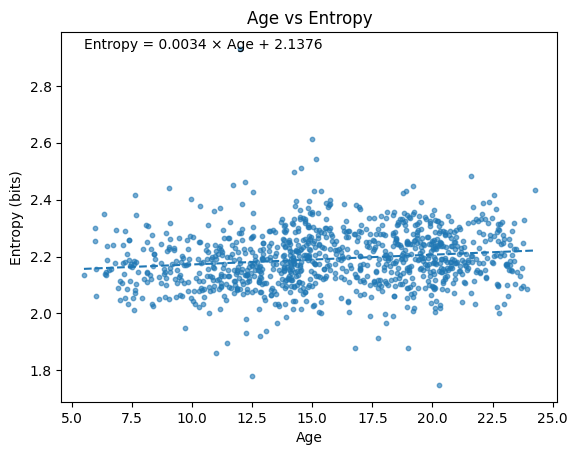

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

age = df_netcc["age"].values
entropy = df_netcc["entropy"].values

# regression
slope, intercept, r, p, _ = linregress(age, entropy)

# scatter
plt.scatter(age, entropy, s=10, alpha=0.6)

# regression line
x = np.linspace(min(age), max(age), 100)
y = slope * x + intercept
plt.plot(x, y, linestyle='--')

# labels
plt.xlabel("Age")
plt.ylabel("Entropy (bits)")
plt.title("Age vs Entropy")

# equation on plot
plt.text(min(age), max(entropy),
         f"Entropy = {slope:.4f} × Age + {intercept:.4f}",
         fontsize=10)

plt.show()

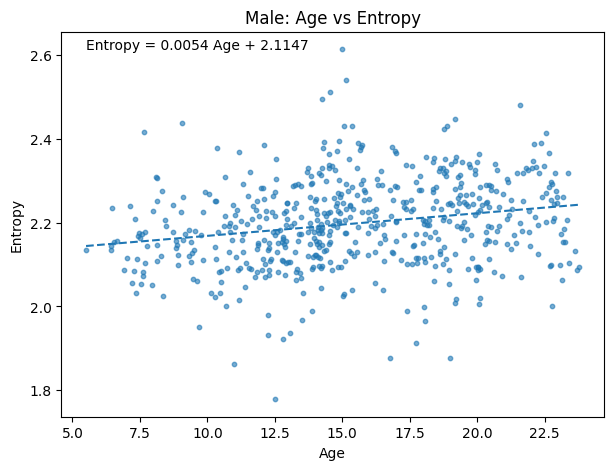

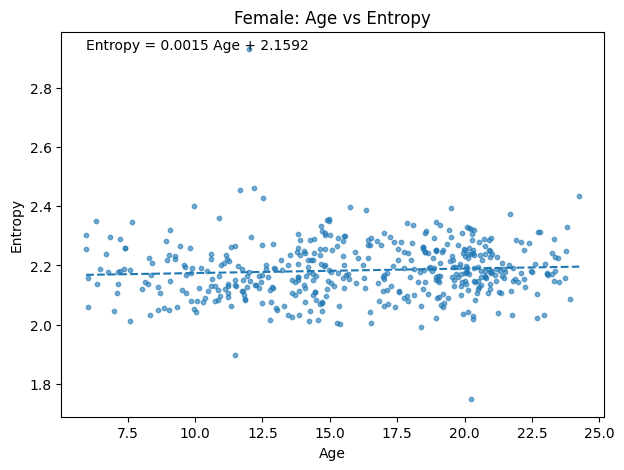

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Male and Female data
male_df = df_netcc[df_netcc["subject"].isin(cveda[cveda["sex"]=="M"]["sub_id"])]
female_df = df_netcc[df_netcc["subject"].isin(cveda[cveda["sex"]=="F"]["sub_id"])]

# ---------- Male Plot ----------
age = male_df["age"].values
entropy = male_df["entropy"].values

slope, intercept, r, p, _ = linregress(age, entropy)

plt.figure(figsize=(7,5))
plt.scatter(age, entropy, s=10, alpha=0.6)
x = np.linspace(min(age), max(age), 100)
plt.plot(x, slope*x + intercept, linestyle='--')

plt.xlabel("Age")
plt.ylabel("Entropy")
plt.title("Male: Age vs Entropy")
plt.text(min(age), max(entropy),
         f"Entropy = {slope:.4f} Age + {intercept:.4f}",
         fontsize=10)
plt.show()


# ---------- Female Plot ----------
age = female_df["age"].values
entropy = female_df["entropy"].values

slope, intercept, r, p, _ = linregress(age, entropy)

plt.figure(figsize=(7,5))
plt.scatter(age, entropy, s=10, alpha=0.6)
x = np.linspace(min(age), max(age), 100)
plt.plot(x, slope*x + intercept, linestyle='--')

plt.xlabel("Age")
plt.ylabel("Entropy")
plt.title("Female: Age vs Entropy")
plt.text(min(age), max(entropy),
         f"Entropy = {slope:.4f} Age + {intercept:.4f}",
         fontsize=10)
plt.show()

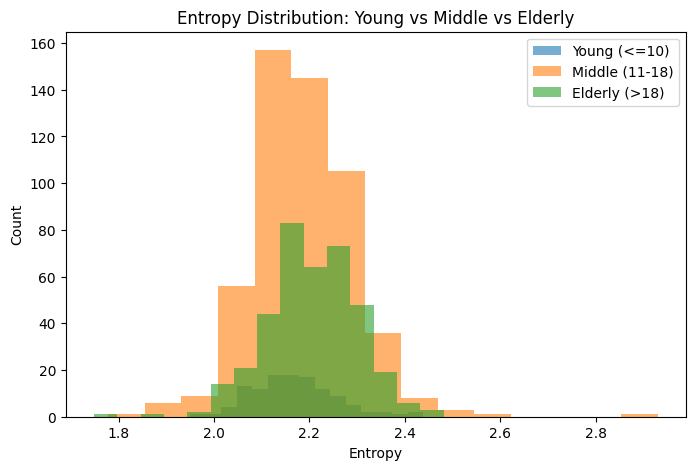

In [ ]:
import matplotlib.pyplot as plt

# 3 groups
young   = df_netcc[df_netcc["age"] <= 10]["entropy"]
middle  = df_netcc[(df_netcc["age"] > 10) & (df_netcc["age"] <= 18)]["entropy"]
elderly = df_netcc[df_netcc["age"] > 18]["entropy"]

# Plot
plt.figure(figsize=(8,5))

plt.hist(young, bins=15, alpha=0.6, label="Young (<=10)")
plt.hist(middle, bins=15, alpha=0.6, label="Middle (11-18)")
plt.hist(elderly, bins=15, alpha=0.6, label="Elderly (>18)")

plt.xlabel("Entropy")
plt.ylabel("Count")
plt.title("Entropy Distribution: Young vs Middle vs Elderly")
plt.legend()

plt.show()

# **REGION DICT**

In [ ]:
import re

text = """
#    N_vox  N_nonnull      frac  #     ROI  ROI_label
      1744       1744   1.00000  #       1  L_Primary_Visual_Cortex
        99         99   1.00000  #       2  L_Medial_Superior_Temporal_Area
       174        174   1.00000  #       3  L_Sixth_Visual_Area
      1185       1185   1.00000  #       4  L_Second_Visual_Area
       880        880   1.00000  #       5  L_Third_Visual_Area
       602        602   1.00000  #       6  L_Fourth_Visual_Area
       176        176   1.00000  #       7  L_Eighth_Visual_Area
      1336       1290   0.96557  #       8  L_Primary_Motor_Cortex
       687        663   0.96507  #       9  L_Primary_Sensory_Cortex
       218        218   1.00000  #      10  L_Frontal_Eye_Fields
       125        125   1.00000  #      11  L_Premotor_Eye_Fields
       309        309   1.00000  #      12  L_Area_55b
       277        277   1.00000  #      13  L_Area_V3A
       343        343   1.00000  #      14  L_RetroSplenial_Complex
       409        409   1.00000  #      15  L_Parieto-Occipital_Sulcus_Area_2
       119        119   1.00000  #      16  L_Seventh_Visual_Area
       221        221   1.00000  #      17  L_IntraParietal_Sulcus_Area_1
       480        480   1.00000  #      18  L_Fusiform_Face_Complex
        82         82   1.00000  #      19  L_Area_V3B
        74         74   1.00000  #      20  L_Area_Lateral_Occipital_1
       144        144   1.00000  #      21  L_Area_Lateral_Occipital_2
       175        175   1.00000  #      22  L_Posterior_InferoTemporal
        79         79   1.00000  #      23  L_Middle_Temporal_Area
       129        129   1.00000  #      24  L_Primary_Auditory_Cortex
       272        272   1.00000  #      25  L_PeriSylvian_Language_Area
       480        472   0.98333  #      26  L_Superior_Frontal_Language_Area
       269        269   1.00000  #      27  L_PreCuneus_Visual_Area
       292        292   1.00000  #      28  L_Superior_Temporal_Visual_Area
       203        203   1.00000  #      29  L_Medial_Area_7P
       277        277   1.00000  #      30  L_Area_7m
       315        315   1.00000  #      31  L_Parieto-Occipital_Sulcus_Area_1
       153        153   1.00000  #      32  L_Area_23d
       112        112   1.00000  #      33  L_Area_ventral_23_a+b
       191        191   1.00000  #      34  L_Area_dorsal_23_a+b
       119        119   1.00000  #      35  L_Area_31p_ventral
       182        182   1.00000  #      36  L_Area_5m
       211        211   1.00000  #      37  L_Area_5m_ventral
       272        272   1.00000  #      38  L_Area_23c
       282        282   1.00000  #      39  L_Area_5L
       330        330   1.00000  #      40  L_Dorsal_Area_24d
       127        127   1.00000  #      41  L_Ventral_Area_24d
       261        261   1.00000  #      42  L_Lateral_Area_7A
       438        419   0.95662  #      43  L_Supplementary_And_Cingulate_Eye
       491        470   0.95723  #      44  L_Area_6m_anterior
       376        376   1.00000  #      45  L_Medial_Area_7A
       210        210   1.00000  #      46  L_Lateral_Area_7P
       395        395   1.00000  #      47  L_Area_7PC
       208        208   1.00000  #      48  L_Area_Lateral_IntraParietal_ventral
       242        242   1.00000  #      49  L_Ventral_IntraParietal_Complex
       237        237   1.00000  #      50  L_Medial_IntraParietal_Area
       812        801   0.98645  #      51  L_Area_1
       529        529   1.00000  #      52  L_Area_2
       278        278   1.00000  #      53  L_Area_3a
       362        362   1.00000  #      54  L_Dorsal_area_6
       461        386   0.83731  #      55  L_Area_6mp
       262        262   1.00000  #      56  L_Ventral_Area_6
       170        170   1.00000  #      57  L_Area_Posterior_24_prime
       162        162   1.00000  #      58  L_Area_33_prime
       131        131   1.00000  #      59  L_Anterior_24_prime
       195        195   1.00000  #      60  L_Area_p32_prime
       254        254   1.00000  #      61  L_Area_a24
       278        278   1.00000  #      62  L_Area_dorsal_32
       398        398   1.00000  #      63  L_Area_8BM
       144        144   1.00000  #      64  L_Area_p32
       197        197   1.00000  #      65  L_Area_10r
       106        106   1.00000  #      66  L_Area_47m
       601        601   1.00000  #      67  L_Area_8Av
       427        427   1.00000  #      68  L_Area_8Ad
       793        791   0.99748  #      69  L_Area_9_Middle
       421        413   0.98100  #      70  L_Area_8B_Lateral
       439        439   1.00000  #      71  L_Area_9_Posterior
       457        457   1.00000  #      72  L_Area_10d
       508        508   1.00000  #      73  L_Area_8C
       298        298   1.00000  #      74  L_Area_44
       471        471   1.00000  #      75  L_Area_45
       313        313   1.00000  #      76  L_Area_47l_(47_lateral)
       509        509   1.00000  #      77  L_Area_anterior_47r
       377        377   1.00000  #      78  L_Rostral_Area_6
       189        189   1.00000  #      79  L_Area_IFJa
       122        122   1.00000  #      80  L_Area_IFJp
       192        192   1.00000  #      81  L_Area_IFSp
       259        259   1.00000  #      82  L_Area__IFSa
       355        355   1.00000  #      83  L_Area_posterior_9-46v
       613        613   1.00000  #      84  L_Area_46
       419        419   1.00000  #      85  L_Area_anterior_9-46v
       551        551   1.00000  #      86  L_Area_9-46d
       466        466   1.00000  #      87  L_Area_9_anterior
       457        457   1.00000  #      88  L_Area_10v
       252        252   1.00000  #      89  L_Area_anterior_10p
       248        248   1.00000  #      90  L_Polar_10p
       446        446   1.00000  #      91  L_Area_11l
       301        301   1.00000  #      92  L_Area_13l
       518        518   1.00000  #      93  L_Orbital_Frontal_Complex
       346        346   1.00000  #      94  L_Area_47s
       130        130   1.00000  #      95  L_Area_Lateral_IntraParietal_dorsal
       529        529   1.00000  #      96  L_Area_6_anterior
       224        224   1.00000  #      97  L_Inferior_6-8_Transitional_Area
       167        167   1.00000  #      98  L_Superior_6-8_Transitional_Area
       236        236   1.00000  #      99  L_Area_43
       286        286   1.00000  #     100  L_Area_OP4/PV
       154        154   1.00000  #     101  L_Area_OP1/SII
       123        123   1.00000  #     102  L_Area_OP2-3/VS
        92         92   1.00000  #     103  L_Area_52
       143        143   1.00000  #     104  L_RetroInsular_Cortex
       177        177   1.00000  #     105  L_Area_PFcm
       340        340   1.00000  #     106  L_Posterior_Insular_Area_2
       190        190   1.00000  #     107  L_Area_TA2
       315        315   1.00000  #     108  L_Frontal_Opercular_Area_4
       260        260   1.00000  #     109  L_Middle_Insular_Area
       318        318   1.00000  #     110  L_Piriform_Cortex
       176        176   1.00000  #     111  L_Anterior_Ventral_Insular_Area
       234        234   1.00000  #     112  L_Anterior_Agranular_Insula_Complex
       104        104   1.00000  #     113  L_Frontal_Opercular_Area_1
        95         95   1.00000  #     114  L_Frontal_Opercular_Area_3
        90         90   1.00000  #     115  L_Frontal_Opercular_Area_2
       251        251   1.00000  #     116  L_Area_PFt
       247        247   1.00000  #     117  L_Anterior_IntraParietal_Area
       276        276   1.00000  #     118  L_Entorhinal_Cortex
       230        230   1.00000  #     119  L_PreSubiculum
       558        558   1.00000  #     120  L_Hippocampus
       154        154   1.00000  #     121  L_ProStriate_Area
       622        622   1.00000  #     122  L_Perirhinal_Ectorhinal_Cortex
       318        318   1.00000  #     123  L_Area_STGa
       215        215   1.00000  #     124  L_ParaBelt_Complex
       411        411   1.00000  #     125  L_Auditory_5_Complex
       156        156   1.00000  #     126  L_ParaHippocampal_Area_1
       253        253   1.00000  #     127  L_ParaHippocampal_Area_3
       243        243   1.00000  #     128  L_Area_STSd_anterior
       248        248   1.00000  #     129  L_Area_STSd_posterior
       368        368   1.00000  #     130  L_Area_STSv_posterior
      1287       1287   1.00000  #     131  L_Area_TG_dorsal
       668        668   1.00000  #     132  L_Area_TE1_anterior
       889        889   1.00000  #     133  L_Area_TE1_posterior
       691        653   0.94501  #     134  L_Area_TE2_anterior
       492        492   1.00000  #     135  L_Area_TF
       515        514   0.99806  #     136  L_Area_TE2_posterior
       522        522   1.00000  #     137  L_Area_PHT
       443        443   1.00000  #     138  L_Area_PH
       263        263   1.00000  #     139  L_Area_TemporoParietoOccipital_Junction_1
       237        237   1.00000  #     140  L_Area_TemporoParietoOccipital_Junction_2
       161        161   1.00000  #     141  L_Area_TemporoParietoOccipital_Junction_3
       224        224   1.00000  #     142  L_Dorsal_Transitional_Visual_Area
       319        319   1.00000  #     143  L_Area_PGp
       260        260   1.00000  #     144  L_Area_IntraParietal_2
       210        210   1.00000  #     145  L_Area_IntraParietal_1
       150        150   1.00000  #     146  L_Area_IntraParietal_0
       221        221   1.00000  #     147  L_Area_PF_opercular
       681        681   1.00000  #     148  L_Area_PF_Complex
      1020       1020   1.00000  #     149  L_Area_PFm_Complex
       599        599   1.00000  #     150  L_Area_PGi
       572        572   1.00000  #     151  L_Area_PGs
       113        113   1.00000  #     152  L_Area_V6A
       112        112   1.00000  #     153  L_VentroMedial_Visual_Area_1
       116        116   1.00000  #     154  L_VentroMedial_Visual_Area_3
        96         96   1.00000  #     155  L_ParaHippocampal_Area_2
       127        127   1.00000  #     156  L_Area_V4t
       166        166   1.00000  #     157  L_Area_FST
       109        109   1.00000  #     158  L_Area_V3CD
        50         50   1.00000  #     159  L_Area_Lateral_Occipital_3
        81         81   1.00000  #     160  L_VentroMedial_Visual_Area_2
       181        181   1.00000  #     161  L_Area_31pd
       162        162   1.00000  #     162  L_Area_31a
       318        318   1.00000  #     163  L_Ventral_Visual_Complex
       239        239   1.00000  #     164  L_Area_25
        73         73   1.00000  #     165  L_Area_s32
       323        323   1.00000  #     166  L_posterior_OFC_Complex
       226        226   1.00000  #     167  L_Area_Posterior_Insular_1
       105        105   1.00000  #     168  L_Insular_Granular_Complex
       165        165   1.00000  #     169  L_Area_Frontal_Opercular
       264        264   1.00000  #     170  L_Area_posterior_10p
       267        267   1.00000  #     171  L_Area_posterior_47r
       449        449   1.00000  #     172  L_Area_TG_Ventral
       157        157   1.00000  #     173  L_Medial_Belt_Complex
       104        104   1.00000  #     174  L_Lateral_Belt_Complex
       433        433   1.00000  #     175  L_Auditory_4_Complex
       213        213   1.00000  #     176  L_Area_STSv_anterior
       410        409   0.99756  #     177  L_Area_TE1_Middle
       129        129   1.00000  #     178  L_Para-Insular_Area
       219        219   1.00000  #     179  L_Area_anterior_32_prime
       295        295   1.00000  #     180  L_Area_posterior_24
      1667       1667   1.00000  #    1001  R_Primary_Visual_Cortex
       123        123   1.00000  #    1002  R_Medial_Superior_Temporal_Area
       198        198   1.00000  #    1003  R_Sixth_Visual_Area
      1182       1182   1.00000  #    1004  R_Second_Visual_Area
       937        937   1.00000  #    1005  R_Third_Visual_Area
       556        556   1.00000  #    1006  R_Fourth_Visual_Area
       145        145   1.00000  #    1007  R_Eighth_Visual_Area
      1282       1186   0.92512  #    1008  R_Primary_Motor_Cortex
       534        494   0.92509  #    1009  R_Primary_Sensory_Cortex
       238        238   1.00000  #    1010  R_Frontal_Eye_Fields
       154        154   1.00000  #    1011  R_Premotor_Eye_Fields
       194        194   1.00000  #    1012  R_Area_55b
       279        279   1.00000  #    1013  R_Area_V3A
       366        366   1.00000  #    1014  R_RetroSplenial_Complex
       392        392   1.00000  #    1015  R_Parieto-Occipital_Sulcus_Area_2
       133        133   1.00000  #    1016  R_Seventh_Visual_Area
       219        219   1.00000  #    1017  R_IntraParietal_Sulcus_Area_1
       546        546   1.00000  #    1018  R_Fusiform_Face_Complex
        90         90   1.00000  #    1019  R_Area_V3B
       115        115   1.00000  #    1020  R_Area_Lateral_Occipital_1
       136        136   1.00000  #    1021  R_Area_Lateral_Occipital_2
       174        174   1.00000  #    1022  R_Posterior_InferoTemporal
       125        125   1.00000  #    1023  R_Middle_Temporal_Area
        99         99   1.00000  #    1024  R_Primary_Auditory_Cortex
       349        349   1.00000  #    1025  R_PeriSylvian_Language_Area
       379        354   0.93404  #    1026  R_Superior_Frontal_Language_Area
       298        298   1.00000  #    1027  R_PreCuneus_Visual_Area
       279        279   1.00000  #    1028  R_Superior_Temporal_Visual_Area
       161        161   1.00000  #    1029  R_Medial_Area_7P
       246        246   1.00000  #    1030  R_Area_7m
       340        340   1.00000  #    1031  R_Parieto-Occipital_Sulcus_Area_1
       201        201   1.00000  #    1032  R_Area_23d
       135        135   1.00000  #    1033  R_Area_ventral_23_a+b
       142        142   1.00000  #    1034  R_Area_dorsal_23_a+b
       132        132   1.00000  #    1035  R_Area_31p_ventral
       258        257   0.99612  #    1036  R_Area_5m
       244        244   1.00000  #    1037  R_Area_5m_ventral
       316        316   1.00000  #    1038  R_Area_23c
       284        267   0.94014  #    1039  R_Area_5L
       341        341   1.00000  #    1040  R_Dorsal_Area_24d
       173        173   1.00000  #    1041  R_Ventral_Area_24d
       249        249   1.00000  #    1042  R_Lateral_Area_7A
       417        416   0.99760  #    1043  R_Supplementary_And_Cingulate_Eye
       536        485   0.90485  #    1044  R_Area_6m_anterior
       293        293   1.00000  #    1045  R_Medial_Area_7A
       169        169   1.00000  #    1046  R_Lateral_Area_7P
       436        436   1.00000  #    1047  R_Area_7PC
       225        225   1.00000  #    1048  R_Area_Lateral_IntraParietal_ventral
       198        198   1.00000  #    1049  R_Ventral_IntraParietal_Complex
       299        299   1.00000  #    1050  R_Medial_IntraParietal_Area
       734        702   0.95640  #    1051  R_Area_1
       598        598   1.00000  #    1052  R_Area_2
       277        277   1.00000  #    1053  R_Area_3a
       369        361   0.97832  #    1054  R_Dorsal_area_6
       377        329   0.87268  #    1055  R_Area_6mp
       312        312   1.00000  #    1056  R_Ventral_Area_6
       222        222   1.00000  #    1057  R_Area_Posterior_24_prime
       164        164   1.00000  #    1058  R_Area_33_prime
       179        179   1.00000  #    1059  R_Anterior_24_prime
       164        164   1.00000  #    1060  R_Area_p32_prime
       266        266   1.00000  #    1061  R_Area_a24
       301        301   1.00000  #    1062  R_Area_dorsal_32
       424        424   1.00000  #    1063  R_Area_8BM
       226        226   1.00000  #    1064  R_Area_p32
       136        136   1.00000  #    1065  R_Area_10r
        97         97   1.00000  #    1066  R_Area_47m
       735        735   1.00000  #    1067  R_Area_8Av
       437        437   1.00000  #    1068  R_Area_8Ad
       744        744   1.00000  #    1069  R_Area_9_Middle
       507        507   1.00000  #    1070  R_Area_8B_Lateral
       306        306   1.00000  #    1071  R_Area_9_Posterior
       384        384   1.00000  #    1072  R_Area_10d
       386        386   1.00000  #    1073  R_Area_8C
       323        323   1.00000  #    1074  R_Area_44
       364        364   1.00000  #    1075  R_Area_45
       324        324   1.00000  #    1076  R_Area_47l_(47_lateral)
       472        472   1.00000  #    1077  R_Area_anterior_47r
       499        499   1.00000  #    1078  R_Rostral_Area_6
       180        180   1.00000  #    1079  R_Area_IFJa
        91         91   1.00000  #    1080  R_Area_IFJp
       217        217   1.00000  #    1081  R_Area_IFSp
       331        331   1.00000  #    1082  R_Area__IFSa
       580        580   1.00000  #    1083  R_Area_posterior_9-46v
       548        548   1.00000  #    1084  R_Area_46
       332        332   1.00000  #    1085  R_Area_anterior_9-46v
       591        591   1.00000  #    1086  R_Area_9-46d
       381        381   1.00000  #    1087  R_Area_9_anterior
       336        336   1.00000  #    1088  R_Area_10v
       217        217   1.00000  #    1089  R_Area_anterior_10p
       290        290   1.00000  #    1090  R_Polar_10p
       478        478   1.00000  #    1091  R_Area_11l
       216        216   1.00000  #    1092  R_Area_13l
       534        534   1.00000  #    1093  R_Orbital_Frontal_Complex
       393        393   1.00000  #    1094  R_Area_47s
       106        106   1.00000  #    1095  R_Area_Lateral_IntraParietal_dorsal
       471        471   1.00000  #    1096  R_Area_6_anterior
       300        300   1.00000  #    1097  R_Inferior_6-8_Transitional_Area
       272        272   1.00000  #    1098  R_Superior_6-8_Transitional_Area
       209        209   1.00000  #    1099  R_Area_43
       308        308   1.00000  #    1100  R_Area_OP4/PV
       137        137   1.00000  #    1101  R_Area_OP1/SII
        97         97   1.00000  #    1102  R_Area_OP2-3/VS
        72         72   1.00000  #    1103  R_Area_52
       167        167   1.00000  #    1104  R_RetroInsular_Cortex
       189        189   1.00000  #    1105  R_Area_PFcm
       340        340   1.00000  #    1106  R_Posterior_Insular_Area_2
       216        216   1.00000  #    1107  R_Area_TA2
       205        205   1.00000  #    1108  R_Frontal_Opercular_Area_4
       249        249   1.00000  #    1109  R_Middle_Insular_Area
       262        262   1.00000  #    1110  R_Piriform_Cortex
       221        221   1.00000  #    1111  R_Anterior_Ventral_Insular_Area
       216        216   1.00000  #    1112  R_Anterior_Agranular_Insula_Complex
       118        118   1.00000  #    1113  R_Frontal_Opercular_Area_1
        75         75   1.00000  #    1114  R_Frontal_Opercular_Area_3
        92         92   1.00000  #    1115  R_Frontal_Opercular_Area_2
       254        254   1.00000  #    1116  R_Area_PFt
       313        313   1.00000  #    1117  R_Anterior_IntraParietal_Area
       286        286   1.00000  #    1118  R_Entorhinal_Cortex
       200        200   1.00000  #    1119  R_PreSubiculum
       511        511   1.00000  #    1120  R_Hippocampus
       133        133   1.00000  #    1121  R_ProStriate_Area
       595        595   1.00000  #    1122  R_Perirhinal_Ectorhinal_Cortex
       269        269   1.00000  #    1123  R_Area_STGa
       190        190   1.00000  #    1124  R_ParaBelt_Complex
       479        479   1.00000  #    1125  R_Auditory_5_Complex
       151        151   1.00000  #    1126  R_ParaHippocampal_Area_1
       144        144   1.00000  #    1127  R_ParaHippocampal_Area_3
       305        305   1.00000  #    1128  R_Area_STSd_anterior
       315        315   1.00000  #    1129  R_Area_STSd_posterior
       312        312   1.00000  #    1130  R_Area_STSv_posterior
      1275       1275   1.00000  #    1131  R_Area_TG_dorsal
       522        522   1.00000  #    1132  R_Area_TE1_anterior
       758        758   1.00000  #    1133  R_Area_TE1_posterior
       702        685   0.97578  #    1134  R_Area_TE2_anterior
       589        589   1.00000  #    1135  R_Area_TF
       376        376   1.00000  #    1136  R_Area_TE2_posterior
       424        424   1.00000  #    1137  R_Area_PHT
       399        399   1.00000  #    1138  R_Area_PH
       503        503   1.00000  #    1139  R_Area_TemporoParietoOccipital_Junction_1
       260        260   1.00000  #    1140  R_Area_TemporoParietoOccipital_Junction_2
       160        160   1.00000  #    1141  R_Area_TemporoParietoOccipital_Junction_3
       280        280   1.00000  #    1142  R_Dorsal_Transitional_Visual_Area
       478        478   1.00000  #    1143  R_Area_PGp
       236        236   1.00000  #    1144  R_Area_IntraParietal_2
       208        208   1.00000  #    1145  R_Area_IntraParietal_1
       150        150   1.00000  #    1146  R_Area_IntraParietal_0
       220        220   1.00000  #    1147  R_Area_PF_opercular
       658        658   1.00000  #    1148  R_Area_PF_Complex
      1015       1015   1.00000  #    1149  R_Area_PFm_Complex
       620        620   1.00000  #    1150  R_Area_PGi
       424        424   1.00000  #    1151  R_Area_PGs
        91         91   1.00000  #    1152  R_Area_V6A
       148        148   1.00000  #    1153  R_VentroMedial_Visual_Area_1
       149        149   1.00000  #    1154  R_VentroMedial_Visual_Area_3
        87         87   1.00000  #    1155  R_ParaHippocampal_Area_2
       150        150   1.00000  #    1156  R_Area_V4t
       208        208   1.00000  #    1157  R_Area_FST
       156        156   1.00000  #    1158  R_Area_V3CD
       114        114   1.00000  #    1159  R_Area_Lateral_Occipital_3
       118        118   1.00000  #    1160  R_VentroMedial_Visual_Area_2
       108        108   1.00000  #    1161  R_Area_31pd
       136        136   1.00000  #    1162  R_Area_31a
       353        353   1.00000  #    1163  R_Ventral_Visual_Complex
       281        281   1.00000  #    1164  R_Area_25
       128        128   1.00000  #    1165  R_Area_s32
       372        372   1.00000  #    1166  R_posterior_OFC_Complex
       220        220   1.00000  #    1167  R_Area_Posterior_Insular_1
       136        136   1.00000  #    1168  R_Insular_Granular_Complex
       164        164   1.00000  #    1169  R_Area_Frontal_Opercular
       293        293   1.00000  #    1170  R_Area_posterior_10p
       222        222   1.00000  #    1171  R_Area_posterior_47r
       526        526   1.00000  #    1172  R_Area_TG_Ventral
       151        151   1.00000  #    1173  R_Medial_Belt_Complex
       104        104   1.00000  #    1174  R_Lateral_Belt_Complex
       447        447   1.00000  #    1175  R_Auditory_4_Complex
       238        238   1.00000  #    1176  R_Area_STSv_anterior
       433        431   0.99538  #    1177  R_Area_TE1_Middle
       130        130   1.00000  #    1178  R_Para-Insular_Area
       142        142   1.00000  #    1179  R_Area_anterior_32_prime
       309        309   1.00000  #    1180  R_Area_posterior_24
"""

region_dict = {}
idx = 0

for line in text.split("\n"):
    match = re.search(r'#\s+\d+\s+(.+)', line)
    if match:
        region_name = match.group(1).strip()
        region_dict[idx] = region_name
        idx += 1

# check
for i in range(10):
    print(i, "->", region_dict[i])

0 -> L_Primary_Visual_Cortex
1 -> L_Medial_Superior_Temporal_Area
2 -> L_Sixth_Visual_Area
3 -> L_Second_Visual_Area
4 -> L_Third_Visual_Area
5 -> L_Fourth_Visual_Area
6 -> L_Eighth_Visual_Area
7 -> L_Primary_Motor_Cortex
8 -> L_Primary_Sensory_Cortex
9 -> L_Frontal_Eye_Fields


# **Method2 **

---



In [ ]:
import os
import numpy as np
import pandas as pd

netcc_folder = "/content/output_folder/Glasser_HCP"

data = []

for _, row in cveda.iterrows():

    subject_id = row["sub_id"]
    age = row["age"]

    file_path = os.path.join(netcc_folder, subject_id + "_000.netcc")

    if not os.path.exists(file_path):
        continue

    # read file
    with open(file_path, "r") as f:
        lines = f.readlines()

    start_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("# CC"):
            start_idx = i + 1
            break

    if start_idx is None:
        continue

    full = np.loadtxt(lines[start_idx:])

    # first 360x360 matrix
    netcc = full[:360, :]

    # ----- entropy for each region -----
    for r in range(360):

        # correlations of region r with other 359 regions
        corr_vals = np.delete(netcc[r, :], r)

        # histogram
        hist, _ = np.histogram(corr_vals, bins=20, range=(-1, 1))

        # probabilities
        p = hist / np.sum(hist)
        p = p[p > 0]

        # entropy
        entropy = -np.sum(p * np.log(p))

        data.append([subject_id, age, r, entropy])

# dataframe
df_region = pd.DataFrame(data, columns=["subject", "age", "region", "entropy"])

df_region.head()


,subject,age,region,entropy
0,sub-000010155078,7.460643,0,2.026260
1,sub-000010155078,7.460643,1,2.022309
2,sub-000010155078,7.460643,2,1.969585
3,sub-000010155078,7.460643,3,2.075919
4,sub-000010155078,7.460643,4,2.057247


In [ ]:
len(df_region)

368640

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

results = []

# each region separately
for r in sorted(df_region["region"].unique()):

    sub_df = df_region[df_region["region"] == r]

    age = sub_df["age"].values
    entropy = sub_df["entropy"].values

    slope, intercept, r_value, p_value, _ = linregress(age, entropy)

    results.append([r, slope, r_value, p_value])

# dataframe of trends
trend_df = pd.DataFrame(results, columns=["region", "slope", "corr", "p"])

trend_df.head()


,region,slope,corr,p
0,0,0.007108,0.165295,1.039821e-07
1,1,-0.000004,-0.000095,9.975896e-01
2,2,0.003907,0.093562,2.727499e-03
3,3,0.005141,0.129795,3.100085e-05
4,4,0.004534,0.117137,1.721300e-04


In [ ]:
# classify regions

increasing = trend_df[trend_df["slope"] > 0]
decreasing = trend_df[trend_df["slope"] < 0]
constant   = trend_df[abs(trend_df["slope"]) < 1e-4]

print("Increasing regions :", len(increasing))
print("Decreasing regions :", len(decreasing))
print("Almost constant    :", len(constant))

Increasing regions : 262
Decreasing regions : 98
Almost constant    : 6


In [ ]:
# Keep only positive slopes, then sort highest to lowest
inc_regions = trend_df[trend_df["slope"] > 0].sort_values("slope", ascending=False)

# Add region names
inc_regions["Region_Name"] = inc_regions["region"].astype(int).map(region_dict)

# Reorder columns
inc_regions = inc_regions[["region", "Region_Name", "slope", "corr", "p"]]

# Export to CSV
inc_regions.to_csv("positive_slopes_descending.csv", index=False)

print("Saved to positive_slopes_descending.csv")

Saved to positive_slopes_descending.csv


Regions: 10  MAE: 3.5287333497016404
Regions: 20  MAE: 3.499926885959118
Regions: 30  MAE: 3.481576124823256
Regions: 40  MAE: 3.480491693878845
Regions: 50  MAE: 3.4518390123288283
Regions: 60  MAE: 3.4227918542209537
Regions: 70  MAE: 3.4174018756640216
Regions: 80  MAE: 3.3901833390528315
Regions: 90  MAE: 3.346017815132279
Regions: 100  MAE: 3.3326636258486206
Regions: 110  MAE: 3.3186655852877602
Regions: 120  MAE: 3.2882173346232326
Regions: 130  MAE: 3.2595381463597937
Regions: 140  MAE: 3.244505932266827
Regions: 150  MAE: 3.2255341520508427
Regions: 160  MAE: 3.2339365680106695
Regions: 170  MAE: 3.2170263335075333
Regions: 180  MAE: 3.201634761473973
Regions: 190  MAE: 3.1535557687164926
Regions: 200  MAE: 3.1347292994213536
Regions: 210  MAE: 3.135409512978424
Regions: 220  MAE: 3.1256637840815666
Regions: 230  MAE: 3.118564556351973
Regions: 240  MAE: 3.1022479812465305
Regions: 250  MAE: 3.096667591035559
Regions: 260  MAE: 3.0792169078624863
Regions: 270  MAE: 3.077022973

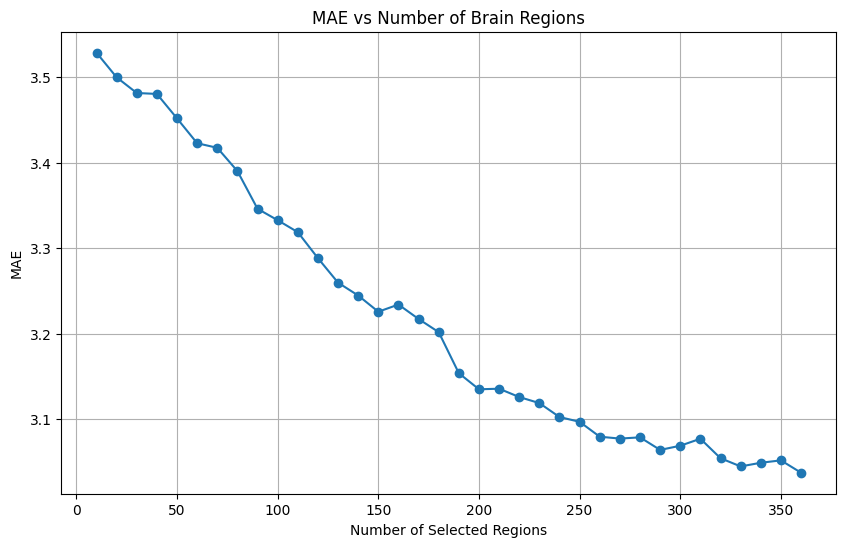

Best k = 360
Lowest MAE = 3.037059216430241


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error

# ---------------------------------
# Prepare data
# ---------------------------------
Xdf = df_region.pivot(index="subject", columns="region", values="entropy")

age_map = df_region.groupby("subject")["age"].first()
Xdf["age"] = age_map
Xdf = Xdf.dropna()

X = Xdf.drop(columns="age").values
y = Xdf["age"].values

# ---------------------------------
# Try different number of regions
# ---------------------------------
k_values = list(range(10, 361, 10))
mae_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_regression, k=k)),
        ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50)))
    ])

    pred = cross_val_predict(model, X, y, cv=kf)
    mae = mean_absolute_error(y, pred)

    mae_scores.append(mae)
    print("Regions:", k, " MAE:", mae)

# ---------------------------------
# Plot
# ---------------------------------
plt.figure(figsize=(10,6))
plt.plot(k_values, mae_scores, marker="o")
plt.xlabel("Number of Selected Regions")
plt.ylabel("MAE")
plt.title("MAE vs Number of Brain Regions")
plt.grid(True)
plt.show()

# Best result
best_idx = np.argmin(mae_scores)
print("Best k =", k_values[best_idx])
print("Lowest MAE =", mae_scores[best_idx])


Best for Positive Slopes
Best k = 260
Lowest MAE = 3.2558
--------------------------------------------------

Best for Negative Slopes
Best k = 90
Lowest MAE = 3.5356
--------------------------------------------------

Best for Absolute Slopes
Best k = 330
Lowest MAE = 3.0176
--------------------------------------------------


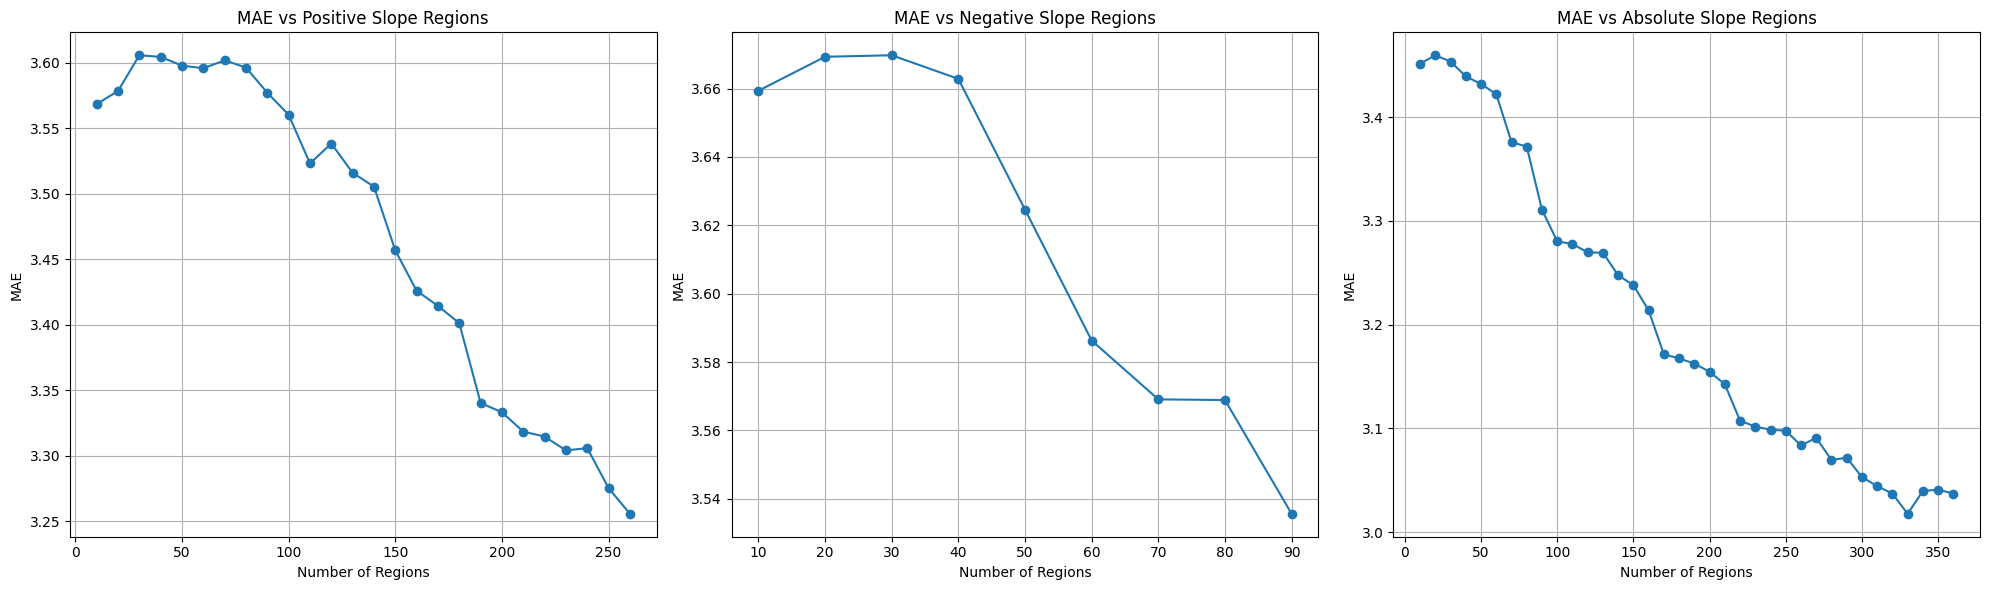

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error

# ---------------------------------
# Prepare ML table
# ---------------------------------
Xdf = df_region.pivot(index="subject", columns="region", values="entropy")

age_map = df_region.groupby("subject")["age"].first()
Xdf["age"] = age_map
Xdf = Xdf.dropna()

y = Xdf["age"].values

# ---------------------------------
# Region sets from trend_df
# ---------------------------------

# Positive slope (largest positive first)
positive_regions = trend_df[trend_df["slope"] > 0] \
    .sort_values("slope", ascending=False)["region"].tolist()

# Negative slope (most negative first)
negative_regions = trend_df[trend_df["slope"] < 0] \
    .sort_values("slope", ascending=True)["region"].tolist()

# Absolute slope (largest change first)
abs_regions = trend_df.iloc[
    trend_df["slope"].abs().sort_values(ascending=False).index
]["region"].tolist()

# ---------------------------------
# CV
# ---------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------
# Function to test region list
# ---------------------------------
def run_test(region_list, title):

    k_values = list(range(10, len(region_list)+1, 10))
    mae_scores = []

    for k in k_values:

        selected = region_list[:k]

        X = Xdf[selected].values

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", RidgeCV(alphas=np.logspace(-3, 3, 50)))
        ])

        pred = cross_val_predict(model, X, y, cv=kf)
        mae = mean_absolute_error(y, pred)

        mae_scores.append(mae)

        # print(title, "| Regions:", k, "| MAE:", round(mae,4))

    best_idx = np.argmin(mae_scores)

    print("\nBest for", title)
    print("Best k =", k_values[best_idx])
    print("Lowest MAE =", round(mae_scores[best_idx],4))
    print("-"*50)

    return k_values, mae_scores

# ---------------------------------
# Run all three
# ---------------------------------
k_pos, mae_pos = run_test(positive_regions, "Positive Slopes")
k_neg, mae_neg = run_test(negative_regions, "Negative Slopes")
k_abs, mae_abs = run_test(abs_regions, "Absolute Slopes")

# ---------------------------------
# Plot 3 graphs
# ---------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Positive
axes[0].plot(k_pos, mae_pos, marker="o")
axes[0].set_title("MAE vs Positive Slope Regions")
axes[0].set_xlabel("Number of Regions")
axes[0].set_ylabel("MAE")
axes[0].grid(True)

# Negative
axes[1].plot(k_neg, mae_neg, marker="o")
axes[1].set_title("MAE vs Negative Slope Regions")
axes[1].set_xlabel("Number of Regions")
axes[1].set_ylabel("MAE")
axes[1].grid(True)

# Absolute
axes[2].plot(k_abs, mae_abs, marker="o")
axes[2].set_title("MAE vs Absolute Slope Regions")
axes[2].set_xlabel("Number of Regions")
axes[2].set_ylabel("MAE")
axes[2].grid(True)

plt.tight_layout()
plt.show()


Best for ElasticNet Positive Slopes
Best k = 250
Lowest MAE = 3.3914
--------------------------------------------------

Best for ElasticNet Negative Slopes
Best k = 80
Lowest MAE = 3.631
--------------------------------------------------

Best for ElasticNet Absolute Slopes
Best k = 350
Lowest MAE = 3.1198
--------------------------------------------------

Best for PLSRegression Positive Slopes
Best k = 200
Lowest MAE = 3.5099
--------------------------------------------------

Best for PLSRegression Negative Slopes
Best k = 60
Lowest MAE = 3.5625
--------------------------------------------------

Best for PLSRegression Absolute Slopes
Best k = 240
Lowest MAE = 3.2674
--------------------------------------------------


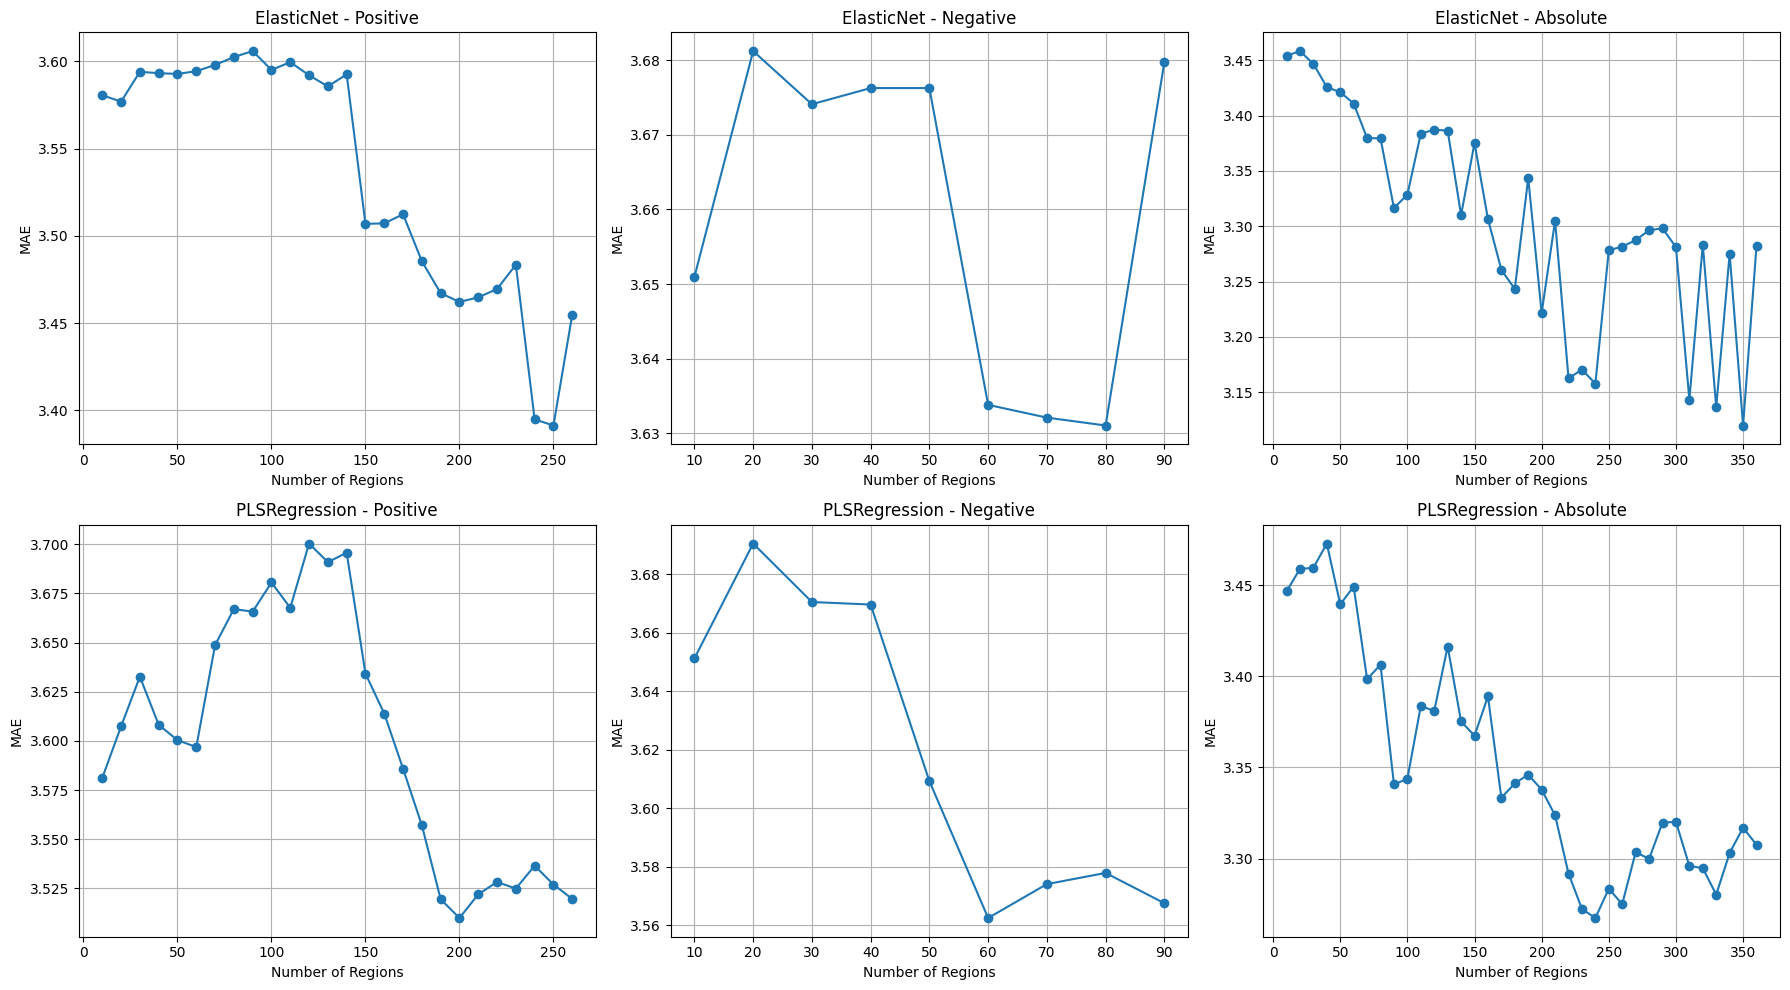


BEST OVERALL
Model: ElasticNet
Region Type: Absolute
Best k: 350
Lowest MAE: 3.1198


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import ElasticNetCV
from sklearn.cross_decomposition import PLSRegression

# ---------------------------------
# Prepare ML table
# ---------------------------------
Xdf = df_region.pivot(index="subject", columns="region", values="entropy")

age_map = df_region.groupby("subject")["age"].first()
Xdf["age"] = age_map
Xdf = Xdf.dropna()

y = Xdf["age"].values

# ---------------------------------
# Region sets from trend_df
# ---------------------------------
positive_regions = trend_df[trend_df["slope"] > 0] \
    .sort_values("slope", ascending=False)["region"].tolist()

negative_regions = trend_df[trend_df["slope"] < 0] \
    .sort_values("slope", ascending=True)["region"].tolist()

abs_regions = trend_df.iloc[
    trend_df["slope"].abs().sort_values(ascending=False).index
]["region"].tolist()

# ---------------------------------
# CV (fast enough for colab CPU)
# ---------------------------------
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# ---------------------------------
# Models
# ---------------------------------
models = {

    "ElasticNet": lambda: Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.3, 0.5, 0.8, 1.0],
            alphas=[0.01, 0.1, 1],
            cv=2,
            max_iter=2000,
            n_jobs=-1
        ))
    ]),

    "PLSRegression": lambda: Pipeline([
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=10))
    ])
}

# ---------------------------------
# Function
# ---------------------------------
def run_test(region_list, title, builder):

    k_values = list(range(10, len(region_list)+1, 10))
    mae_scores = []

    for k in k_values:

        selected = region_list[:k]
        X = Xdf[selected].values

        model = builder()

        pred = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)
        pred = pred.ravel()

        mae = mean_absolute_error(y, pred)
        mae_scores.append(mae)

    best_idx = np.argmin(mae_scores)

    print("\nBest for", title)
    print("Best k =", k_values[best_idx])
    print("Lowest MAE =", round(mae_scores[best_idx],4))
    print("-"*50)

    return k_values, mae_scores

# ---------------------------------
# Run all models
# ---------------------------------
results = {}

for model_name, builder in models.items():

    results[model_name] = {}

    results[model_name]["Positive"] = run_test(
        positive_regions, model_name + " Positive Slopes", builder
    )

    results[model_name]["Negative"] = run_test(
        negative_regions, model_name + " Negative Slopes", builder
    )

    results[model_name]["Absolute"] = run_test(
        abs_regions, model_name + " Absolute Slopes", builder
    )

# ---------------------------------
# Plot
# 2 rows x 3 columns
# ---------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18,10))

model_names = list(results.keys())
region_types = ["Positive", "Negative", "Absolute"]

for i, model_name in enumerate(model_names):
    for j, region_type in enumerate(region_types):

        k_vals, maes = results[model_name][region_type]

        ax = axes[i, j]
        ax.plot(k_vals, maes, marker="o")
        ax.set_title(f"{model_name} - {region_type}")
        ax.set_xlabel("Number of Regions")
        ax.set_ylabel("MAE")
        ax.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------
# Best Overall
# ---------------------------------
best_model = None
best_type = None
best_k = None
best_mae = 999

for model_name in results:
    for region_type in results[model_name]:

        k_vals, maes = results[model_name][region_type]

        idx = np.argmin(maes)

        if maes[idx] < best_mae:
            best_mae = maes[idx]
            best_model = model_name
            best_type = region_type
            best_k = k_vals[idx]

print("\nBEST OVERALL")
print("Model:", best_model)
print("Region Type:", best_type)
print("Best k:", best_k)
print("Lowest MAE:", round(best_mae,4))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import ElasticNetCV
from sklearn.cross_decomposition import PLSRegression

# ---------------------------------
# Prepare ML table
# ---------------------------------
Xdf = df_region.pivot(index="subject", columns="region", values="entropy")

age_map = df_region.groupby("subject")["age"].first()
Xdf["age"] = age_map
Xdf = Xdf.dropna()

y = Xdf["age"].values

# ---------------------------------
# Region sets from trend_df
# ---------------------------------
positive_regions = trend_df[trend_df["slope"] > 0] \
    .sort_values("slope", ascending=False)["region"].tolist()

negative_regions = trend_df[trend_df["slope"] < 0] \
    .sort_values("slope", ascending=True)["region"].tolist()

abs_regions = trend_df.iloc[
    trend_df["slope"].abs().sort_values(ascending=False).index
]["region"].tolist()

# ---------------------------------
# Stronger CV (slower, better)
# ---------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ---------------------------------
# Models
# ---------------------------------
models = {

    "ElasticNet": lambda: Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
            alphas=np.logspace(-4, 2, 15),
            cv=5,
            max_iter=5000,
            n_jobs=-1
        ))
    ])
}

# ---------------------------------
# PLS builder (depends on k)
# ---------------------------------
def build_pls(k):

    n_comp = min(15, k, len(Xdf)-1)

    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", PLSRegression(n_components=n_comp))
    ])

# ---------------------------------
# Function
# ---------------------------------
def run_test(region_list, title, model_name):

    k_values = list(range(10, len(region_list)+1, 5))
    mae_scores = []

    for k in k_values:

        selected = region_list[:k]
        X = Xdf[selected].values

        if model_name == "PLSRegression":
            model = build_pls(k)
        else:
            model = models[model_name]()

        pred = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)
        pred = pred.ravel()

        mae = mean_absolute_error(y, pred)
        mae_scores.append(mae)

    best_idx = np.argmin(mae_scores)

    print("\nBest for", title)
    print("Best k =", k_values[best_idx])
    print("Lowest MAE =", round(mae_scores[best_idx],4))
    print("-"*50)

    return k_values, mae_scores

# ---------------------------------
# Run all models
# ---------------------------------
model_names = ["ElasticNet", "PLSRegression"]

results = {}

for model_name in model_names:

    results[model_name] = {}

    results[model_name]["Positive"] = run_test(
        positive_regions, model_name + " Positive", model_name
    )

    results[model_name]["Negative"] = run_test(
        negative_regions, model_name + " Negative", model_name
    )

    results[model_name]["Absolute"] = run_test(
        abs_regions, model_name + " Absolute", model_name
    )

# ---------------------------------
# Plot
# ---------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18,10))

region_types = ["Positive", "Negative", "Absolute"]

for i, model_name in enumerate(model_names):
    for j, region_type in enumerate(region_types):

        k_vals, maes = results[model_name][region_type]

        ax = axes[i, j]
        ax.plot(k_vals, maes, marker="o")
        ax.set_title(f"{model_name} - {region_type}")
        ax.set_xlabel("Number of Regions")
        ax.set_ylabel("MAE")
        ax.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------
# Best Overall
# ---------------------------------
best_model = None
best_type = None
best_k = None
best_mae = 999

for model_name in results:
    for region_type in results[model_name]:

        k_vals, maes = results[model_name][region_type]

        idx = np.argmin(maes)

        if maes[idx] < best_mae:
            best_mae = maes[idx]
            best_model = model_name
            best_type = region_type
            best_k = k_vals[idx]

print("\nBEST OVERALL")
print("Model:", best_model)
print("Region Type:", best_type)
print("Best k:", best_k)
print("Lowest MAE:", round(best_mae,4))


Best for ElasticNet Positive
Best k = 260
Lowest MAE = 3.2775
--------------------------------------------------

Best for ElasticNet Negative
Best k = 90
Lowest MAE = 3.5354
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# ---------------------------------
# Prepare data
# ---------------------------------
Xdf = df_region.pivot(index="subject", columns="region", values="entropy")
age_map = df_region.groupby("subject")["age"].first()
Xdf["age"] = age_map
Xdf = Xdf.dropna()

X = Xdf.drop(columns="age").values
y = Xdf["age"].values

# ---------------------------------
# Sweep k
# ---------------------------------
k_values = list(range(10, X.shape[1]+1, 10))
mae_scores = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=mutual_info_regression, k=k)),
        ("model",  GradientBoostingRegressor(
                       n_estimators=300, max_depth=3,
                       learning_rate=0.05, subsample=0.8,
                       random_state=42))
    ])
    pred = cross_val_predict(model, X, y, cv=kf)
    mae  = mean_absolute_error(y, pred)
    mae_scores.append(mae)
    print(f"k={k:4d}  MAE={mae:.4f}")

# ---------------------------------
# Plot
# ---------------------------------
best_idx = np.argmin(mae_scores)
best_k   = k_values[best_idx]
best_mae = mae_scores[best_idx]

plt.figure(figsize=(9, 5))
plt.plot(k_values, mae_scores, marker="o", color="steelblue")
plt.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}  MAE={best_mae:.3f}")
plt.xlabel("Number of Selected Regions")
plt.ylabel("MAE (years)")
plt.title("GradientBoosting – MAE vs Number of Brain Regions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

k=  10  MAE=3.5747
k=  20  MAE=3.4780


KeyboardInterrupt: 


Running: Ridge

Running: ElasticNet

Running: XGBoost


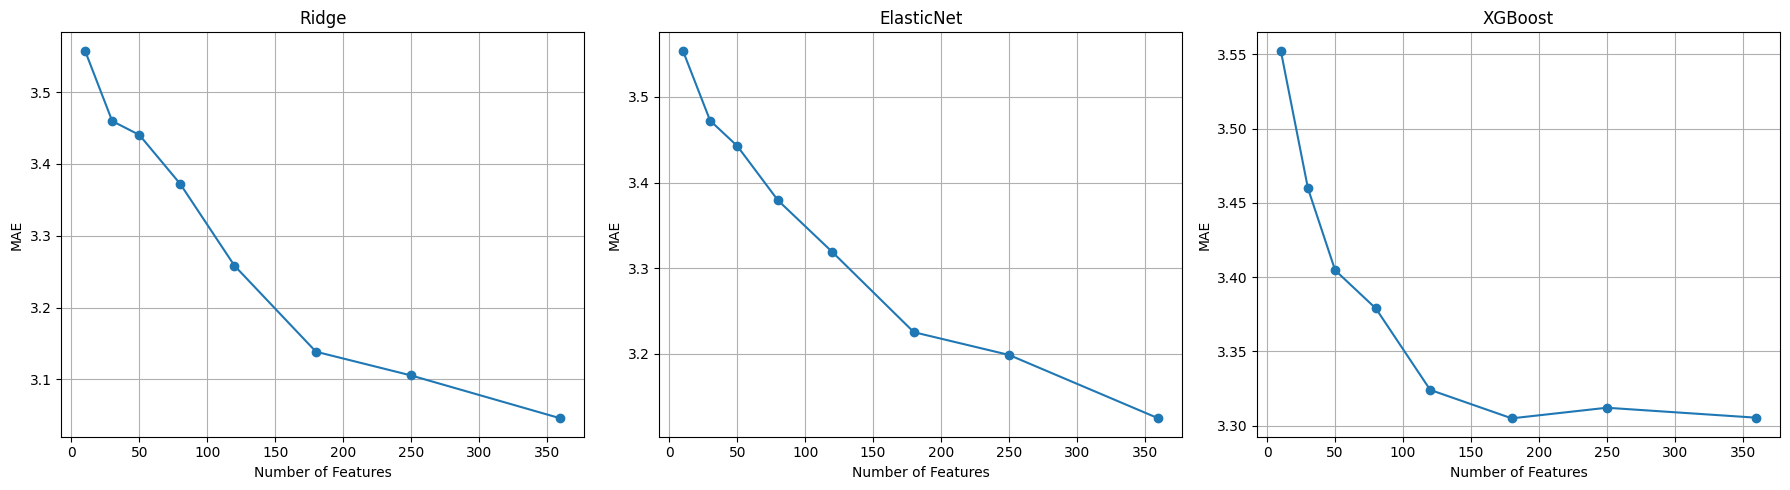


Best Overall Model: Ridge
Best Number of Features: 360
Lowest MAE: 3.0457


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import RidgeCV, ElasticNetCV
from xgboost import XGBRegressor

# ---------------------------------
# Prepare data
# ---------------------------------
Xdf = df_region.pivot(index="subject", columns="region", values="entropy")

age_map = df_region.groupby("subject")["age"].first()
Xdf["age"] = age_map

Xdf = Xdf.dropna()

X = Xdf.drop(columns="age").values
y = Xdf["age"].values

# ---------------------------------
# Feature counts to test
# Reduced for speed
# ---------------------------------
k_values = [10, 30, 50, 80, 120, 180, 250, 360]

# ---------------------------------
# CV
# Reduced folds for speed
# ---------------------------------
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# ---------------------------------
# Models
# ---------------------------------
models = {

    # KEEP RIDGE SAME
    "Ridge": lambda k: Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_regression, k=k)),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 50)))
    ]),

    # MAX SPEED ELASTICNET
    "ElasticNet": lambda k: Pipeline([
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_regression, k=k)),
        ("model", ElasticNetCV(
            l1_ratio=[0.5, 1.0],
            alphas=[0.01, 0.1, 1],
            cv=2,
            max_iter=1500,
            n_jobs=-1
        ))
    ]),

    # MAX SPEED XGBOOST
    "XGBoost": lambda k: Pipeline([
        ("select", SelectKBest(f_regression, k=k)),
        ("model", XGBRegressor(
            n_estimators=60,
            learning_rate=0.1,
            max_depth=2,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ))
    ])
}

# ---------------------------------
# Run all models
# ---------------------------------
all_results = {}

for model_name, build_model in models.items():

    maes = []

    print("\nRunning:", model_name)

    for k in k_values:

        model = build_model(k)

        pred = cross_val_predict(model, X, y, cv=kf, n_jobs=-1)
        mae = mean_absolute_error(y, pred)

        maes.append(mae)

        # print("Features:", k, " MAE:", round(mae,4))

    all_results[model_name] = maes

# ---------------------------------
# Plot
# ---------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.ravel()

for idx, (model_name, maes) in enumerate(all_results.items()):

    ax = axes[idx]

    ax.plot(k_values, maes, marker="o")
    ax.set_title(model_name)
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("MAE")
    ax.grid(True)

plt.tight_layout()
plt.show()

# ---------------------------------
# Best overall
# ---------------------------------
best_model = None
best_k = None
best_mae = 999

for model_name, maes in all_results.items():

    i = np.argmin(maes)

    if maes[i] < best_mae:
        best_mae = maes[i]
        best_k = k_values[i]
        best_model = model_name

print("\nBest Overall Model:", best_model)
print("Best Number of Features:", best_k)
print("Lowest MAE:", round(best_mae,4))


In [ ]:
# ---------------------------------
# Best k + MAE for every model
# ---------------------------------
print("\nBest Results For Each Model:\n")

for model_name, maes in all_results.items():

    i = np.argmin(maes)
    best_k_model = k_values[i]
    best_mae_model = maes[i]

    print(model_name)
    print("Best Features (k):", best_k_model)
    print("Lowest MAE:", round(best_mae_model, 4))
    print("-" * 30)


Best Results For Each Model:

Ridge
Best Features (k): 360
Lowest MAE: 3.0457
------------------------------
ElasticNet
Best Features (k): 360
Lowest MAE: 3.1247
------------------------------
XGBoost
Best Features (k): 180
Lowest MAE: 3.305
------------------------------


In [ ]:
# Keep only negative slopes, then sort most negative first
# Example: -0.010 comes before -0.001
neg_regions = trend_df[trend_df["slope"] < 0].sort_values("slope", ascending=True)

# Add region names
neg_regions["Region_Name"] = neg_regions["region"].astype(int).map(region_dict)

# Reorder columns
neg_regions = neg_regions[["region", "Region_Name", "slope", "corr", "p"]]

# Export to CSV
neg_regions.to_csv("strongest_negative_slopes.csv", index=False)

print("Saved to strongest_negative_slopes.csv")

Saved to strongest_negative_slopes.csv


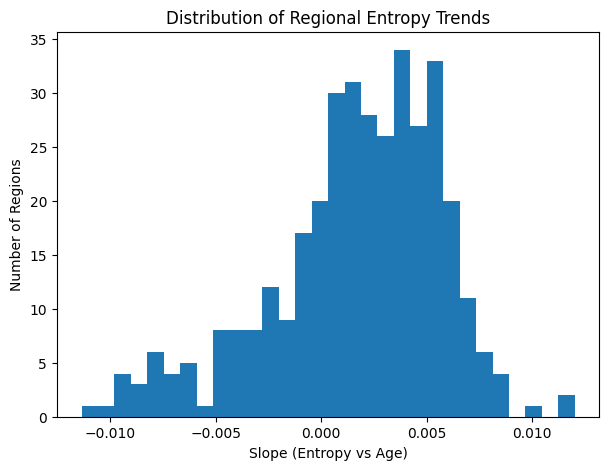

In [ ]:
# histogram of slopes

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(trend_df["slope"], bins=30)

plt.xlabel("Slope (Entropy vs Age)")
plt.ylabel("Number of Regions")
plt.title("Distribution of Regional Entropy Trends")

plt.show()

# **Comparing whole brain vs per region entropy**

In [ ]:
# mean of 360 regional entropies for each subject
mean_regional = (
    df_region.groupby("subject")["entropy"]
    .mean()
    .reset_index()
    .rename(columns={"entropy": "mean_regional_entropy"})
)

# merge with whole-brain entropy
df_compare = df_netcc.merge(mean_regional, on="subject")

df_compare.head()

,subject,age,entropy,age_group,mean_regional_entropy
0,sub-000010155078,7.460643,2.175262,5-10,1.985040
1,sub-000010218000,14.039699,2.249519,10-15,2.053300
2,sub-000010225245,16.761123,2.278160,15-20,2.081707
3,sub-000010229783,16.473648,2.290527,15-20,2.116936
4,sub-000010382566,22.631075,2.205253,20-25,2.031428


In [ ]:
df_compare["difference"] = (
    df_compare["entropy"] - df_compare["mean_regional_entropy"]
)

df_compare["difference"].describe()

,difference
count,1024.000000
mean,0.178144
std,0.045515
min,0.084420
25%,0.146987
50%,0.171943
75%,0.200851
max,0.408071


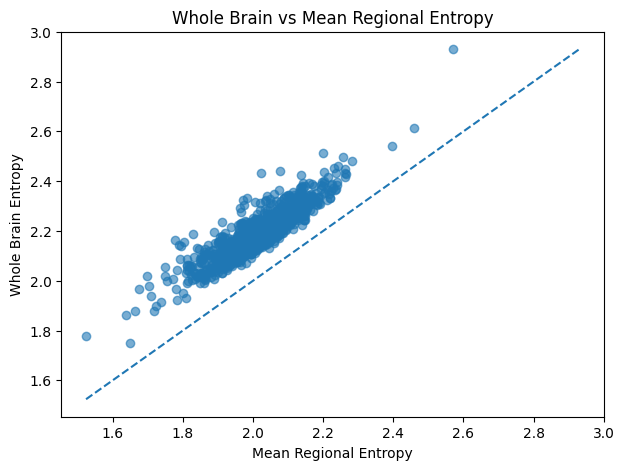

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(df_compare["mean_regional_entropy"],
            df_compare["entropy"], alpha=0.6)

mn = min(df_compare["mean_regional_entropy"].min(),
         df_compare["entropy"].min())

mx = max(df_compare["mean_regional_entropy"].max(),
         df_compare["entropy"].max())

plt.plot([mn,mx],[mn,mx],'--')

plt.xlabel("Mean Regional Entropy")
plt.ylabel("Whole Brain Entropy")
plt.title("Whole Brain vs Mean Regional Entropy")

plt.show()